In [103]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import seaborn as sns

mean: 0.748, std: 0.036


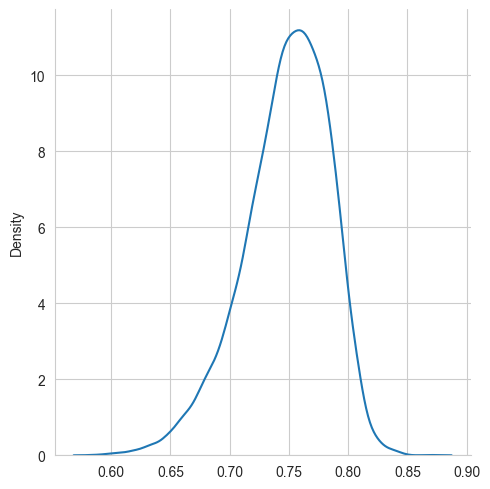

In [104]:
# Inheritable defensive trait (thickness of shell, etc)

def simulate_defensive_trait(n_prey=1000, n_steps=100, max_prey=10000):
    x = np.full(n_prey,0.5) # All prey start with average defensive trait
    for t in range(n_steps):
        r = np.random.rand(len(x))
        survivors = x[r < x] # Randomly kill prey, stronger defensive trait -> higher chance of surviving

        x = np.repeat(survivors, np.where(survivors > 0.8, 1, 2)) # Too high - disadvantage to reproduction

        mutation = np.random.normal(loc=0, scale=0.01, size=len(x)) # Offspring has the same trait as parents plus a random mutation distributed normally
        x += mutation
        x = np.clip(x, 0, 1) # 0 =< x =< 1

        if len(x) > max_prey: # Kill random prey to keep simulation size manageable - will not affect distribution
            np.random.shuffle(x)
            x = x[:max_prey]
    return x

data = simulate_defensive_trait()
mean =np.mean(data)
std = np.std(data)
sns.displot(data, kind='kde')
print(f"mean: {np.mean(data):.3f}, std: {np.std(data):.3f}")

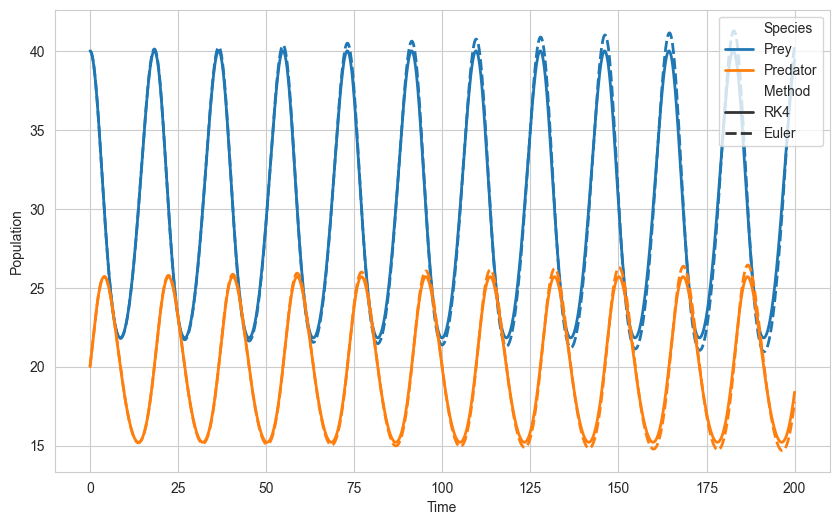

In [105]:
# Lotka-Volterra model
prey_growth_rate = 0.4 #alpha
predation_rate = 0.02 #beta
pred_death_rate = 0.3 #gamma
reproduction_rate = 0.01 #delta
prey_capacity = 200
n_steps = 20000
dt = 0.01
logistic_model = False
initial_state = np.array([40,20])


def rk4_step(f, t, state, dt):
    k1 = f(t, state)
    k2 = f(t + dt/2, state + k1*dt/2)
    k3 = f(t + dt/2, state + k2*dt/2)
    k4 = f(t + dt,   state + k3*dt)
    return state + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

def euler_step(f, t, state, dt):
    return state + f(t, state) * dt

def simulate(f, step_function, state0, dt, n_steps):
    states = np.zeros((n_steps, len(state0)))
    t = 0
    state = state0
    for i in range(n_steps):
        states[i] = state
        state = step_function(f, t, state, dt)
        t += dt
    return states

def make_lotka_volterra(a,b,g,d,K):
    def f(t, state):
        x,y = state
        if logistic_model:
            dx = a*x*(1-x/K) - b*x*y
        else:
            dx = a*x - b*x*y
        dy = -g*y + d*x*y
        return np.array([dx, dy])
    return f

f = make_lotka_volterra(prey_growth_rate, predation_rate, pred_death_rate, reproduction_rate, prey_capacity)
times = np.arange(n_steps)*dt

df_rk4 = pd.DataFrame(simulate(f, rk4_step, initial_state ,dt, n_steps), columns=['Prey', 'Predator'])
df_rk4['Time'] = times
df_euler = pd.DataFrame(simulate(f, euler_step, initial_state ,dt, n_steps), columns=['Prey', 'Predator'])
df_euler['Time'] = times
df_euler['Method'] = 'Euler'
df_rk4['Method'] = 'RK4'
df = pd.concat([df_rk4, df_euler])
df_melted = df.melt(id_vars=['Time', 'Method'], var_name='Species', value_name='Population')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='Time', y='Population', hue='Species', style='Method', linewidth=2)
plt.legend(loc='upper right')
plt.show()

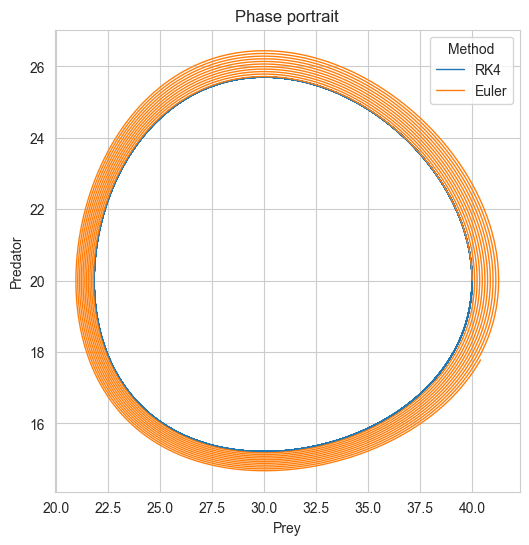

In [106]:
plt.figure(figsize=(6, 6))
sns.lineplot(data=df, x='Prey', y='Predator', hue='Method', sort=False, lw=1)
plt.title("Phase portrait")
plt.show()

Text(0.5, 1.0, 'Conserved quantity over time')

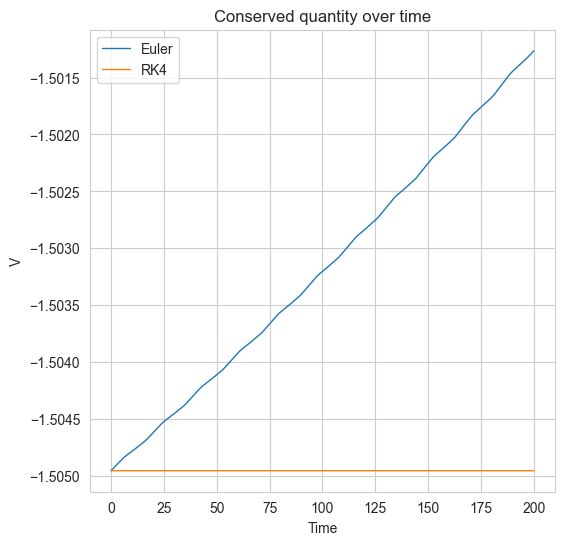

In [107]:
df_euler['V'] = (reproduction_rate * df_euler['Prey']- pred_death_rate * np.log(df_euler['Prey'])+ predation_rate * df_euler['Predator'] - prey_growth_rate * np.log(df_euler['Predator']))
df_rk4['V'] = (reproduction_rate * df_rk4['Prey']- pred_death_rate * np.log(df_rk4['Prey'])+ predation_rate * df_rk4['Predator'] - prey_growth_rate * np.log(df_rk4['Predator']))
plt.figure(figsize=(6, 6))
sns.lineplot(data=df_euler, x='Time', y='V', sort=False, lw=1, label='Euler')
sns.lineplot(data=df_rk4, x='Time', y='V', sort=False, lw=1, label='RK4')
plt.title("Conserved quantity over time")